In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/file_paths.csv
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.multitrack-mridangam-right.mp3
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.json
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.sama-manual.txt
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.multitrack-ghatam.mp3
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.bpm-manual.txt
/kaggle/input/

In [19]:
# ==========================================================
# Cell 1 : Install Required Packages
# ==========================================================

!pip -q install torchcrepe librosa soundfile tqdm

In [2]:
import os

PROJECT = "/kaggle/working/SwaraFormer"

folders = [
    "notebooks",
    "models",
    "utils",
    "dataset",
    "dataset/subset",
    "dataset/processed",
    "dataset/embeddings",
    "checkpoints",
    "results",
    "results/figures",
    "results/confusion_matrix",
    "results/logs"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT, folder), exist_ok=True)

print("Project created successfully.")

Project created successfully.


In [3]:
files = [
    "config.py",

    "models/__init__.py",
    "models/encoder.py",
    "models/transformer.py",
    "models/bilstm.py",
    "models/conformer.py",
    "models/losses.py",

    "utils/__init__.py",
    "utils/audio.py",
    "utils/features.py",
    "utils/dataset.py",
    "utils/metrics.py",
    "utils/visualization.py",
]

for f in files:

    path = os.path.join(PROJECT, f)

    with open(path, "w") as fp:
        fp.write("")

print("Python files created.")

Python files created.


In [4]:
# ==========================================================
# Cell 1 : Install Dependencies
# ==========================================================

!pip install -q torchcrepe librosa soundfile audiomentations
!pip install -q pandas numpy matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 22.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.1 MB/s eta 0:00:00:00:01


In [5]:
# ==========================================================
# Cell 2 : Imports
# ==========================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import soundfile as sf

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchcrepe

In [9]:
# ==========================================================
# Cell 3 : Configuration
# ==========================================================

# Root dataset directory
DATASET_DIR = "/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic"

# Project directory
PROJECT_DIR = "/kaggle/working/SwaraFormer"

# Audio
SAMPLE_RATE = 16000

# Spectrogram
N_MELS = 64
FFT_SIZE = 1024
HOP_LENGTH = 160

# Windowing
WINDOW_SIZE = 256

# Small subset for development
SUBSET_SIZE = 20

# Random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", DEVICE)

Device : cpu


In [10]:
# ==========================================================
# Cell 4 : Create Project Structure
# ==========================================================

folders = [

    "dataset",

    "dataset/raw",

    "dataset/subset",

    "dataset/processed",

    "dataset/embeddings",

    "models",

    "utils",

    "results",

    "results/figures",

    "results/logs",

    "checkpoints"

]

for folder in folders:

    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project structure created successfully.")

Project structure created successfully.


In [11]:
# ==========================================================
# Cell 5 : Index Dataset
# ==========================================================

songs = []

for root, dirs, files in os.walk(DATASET_DIR):

    audio = None
    pitch = None
    tonic = None
    metadata = None

    for f in files:

        if f.endswith(".mp3.mp3"):

            audio = os.path.join(root, f)

        elif f.endswith(".pitch.txt"):

            pitch = os.path.join(root, f)

        elif f.endswith(".ctonic.txt"):

            tonic = os.path.join(root, f)

        elif f.endswith(".json"):

            metadata = os.path.join(root, f)

    if audio and pitch and tonic:

        songs.append({

            "audio": audio,

            "pitch": pitch,

            "tonic": tonic,

            "json": metadata

        })

songs_df = pd.DataFrame(songs)

print("Total Songs :", len(songs_df))

songs_df.head()

Total Songs : 116


,audio,pitch,tonic,json
0,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
1,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
2,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
3,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
4,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...


In [12]:
# ==========================================================
# Cell 6 : Create Subset
# ==========================================================

subset_df = songs_df.sample(

    n=min(SUBSET_SIZE, len(songs_df)),

    random_state=SEED

).reset_index(drop=True)

print("Subset Size :", len(subset_df))

Subset Size : 20


In [13]:
# ==========================================================
# Cell 7 : Audio Loader
# ==========================================================

def load_audio(path):

    audio, sr = librosa.load(

        path,

        sr=SAMPLE_RATE,

        mono=True

    )

    return audio.astype(np.float32)

In [14]:
# ==========================================================
# Cell 8 : Pitch Loader
# ==========================================================

def load_pitch(path):

    data = np.loadtxt(path)

    time = data[:,0]

    pitch = data[:,1]

    return time, pitch

In [15]:
# ==========================================================
# Cell 9 : Tonic Loader
# ==========================================================

def load_tonic(path):

    with open(path) as f:

        tonic = float(f.readline())

    return tonic

In [16]:
# ==========================================================
# Cell 10 : Metadata Loader
# ==========================================================

import json

def load_metadata(path):

    if path is None:
        return {}

    with open(path) as f:

        meta = json.load(f)

    return meta

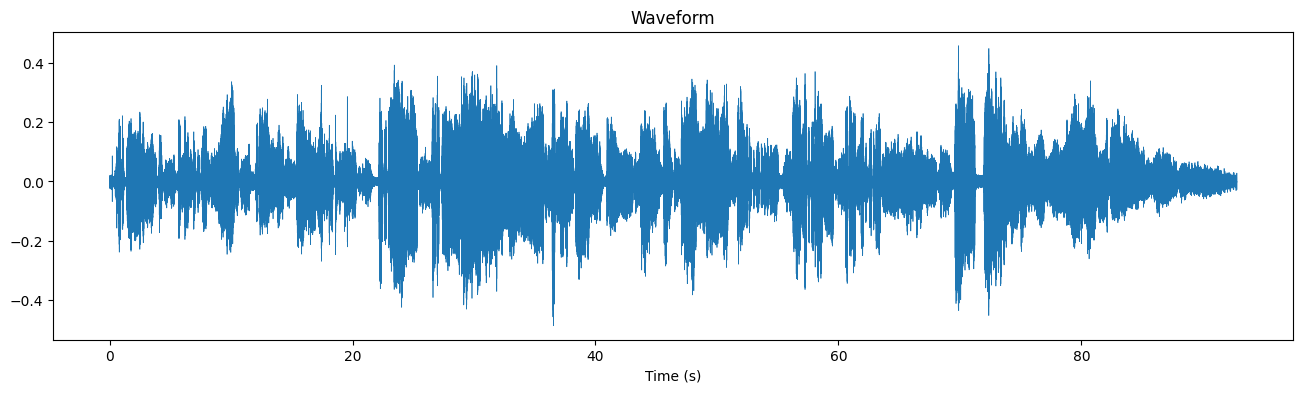

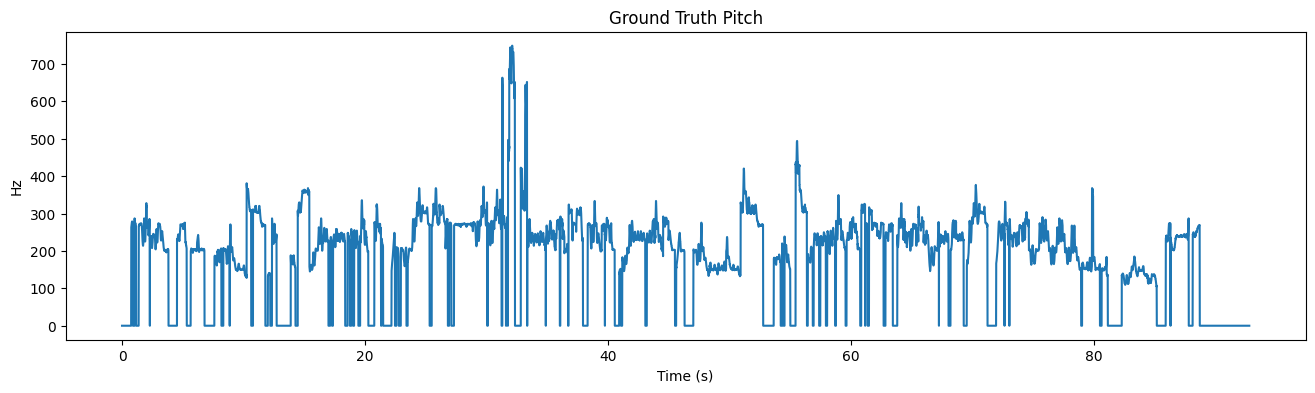

Duration : 92.801125
Frames : 20884
Tonic : 135.425885
Metadata:
{'mbid': 'ac58786c-3938-4d93-9e9f-bbc3a56265fa', 'title': 'Shlokam - Shivah Shaktyayukto', 'length': 92000, 'artists': [{'artist': {'mbid': '19f93366-5d58-47f1-bc4f-9225ac7af6ba', 'name': 'N Guruprasad'}, 'instrument': {'mbid': 'c5aa7d98-c14d-4ff1-8afb-f8743c62496c', 'name': 'Ghatam'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': '39c1d741-6154-418b-bf4b-12c77ba13873', 'name': 'Srimushnam V Raja Rao'}, 'instrument': {'mbid': 'f689271c-37bc-4c49-92a3-a14b15ee5d0e', 'name': 'Mridangam'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': 'a2df55e3-d141-4767-862e-77adca691d4b', 'name': 'B.U. Ganesh Prasad'}, 'instrument': {'mbid': '089f123c-0f7d-4105-a64e-49de81ca8fa4', 'name': 'Violin'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': 'e09b0542-84e1-45ad-b09a-a05a9ad0cb83', 'name': 'Cherthala Ranganatha Sharma'}, 'instrument': {'mbid': 'd92884b7-ee0c-46d5-96f3-918196ba8c5b', 'name': 'Voice'}, 'lead': True,

In [17]:
# ==========================================================
# Cell 11 : Visualize One Song
# ==========================================================

row = subset_df.iloc[0]

audio = load_audio(row.audio)

time, pitch = load_pitch(row.pitch)

tonic = load_tonic(row.tonic)

meta = load_metadata(row.json)

plt.figure(figsize=(16,4))

plt.plot(
    np.arange(len(audio))/SAMPLE_RATE,
    audio,
    linewidth=0.5
)

plt.title("Waveform")

plt.xlabel("Time (s)")

plt.show()

plt.figure(figsize=(16,4))

plt.plot(time, pitch)

plt.title("Ground Truth Pitch")

plt.xlabel("Time (s)")

plt.ylabel("Hz")

plt.show()

print("="*60)

print("Duration :", len(audio)/SAMPLE_RATE)

print("Frames :", len(pitch))

print("Tonic :", tonic)

print("Metadata:")

print(meta)

In [19]:
!git clone https://github.com/singlabhawnasingla-ux/SwaraFormer

fatal: destination path 'SwaraFormer' already exists and is not an empty directory.


In [20]:
%cd /kaggle/working/SwaraFormer

/kaggle/working/SwaraFormer


In [21]:
!ls -la

total 32
drwxr-xr-x 8 root root 4096 Jul 15 04:16 .
drwxr-xr-x 5 root root 4096 Jul 15 04:16 ..
drwxr-xr-x 2 root root 4096 Jul 15 04:16 checkpoints
-rw-r--r-- 1 root root    0 Jul 15 04:16 config.py
drwxr-xr-x 6 root root 4096 Jul 15 04:22 dataset
drwxr-xr-x 2 root root 4096 Jul 15 04:16 models
drwxr-xr-x 2 root root 4096 Jul 15 04:16 notebooks
drwxr-xr-x 5 root root 4096 Jul 15 04:16 results
drwxr-xr-x 2 root root 4096 Jul 15 04:16 utils


In [22]:
%cd /kaggle/working
!rm -rf SwaraFormer

/kaggle/working


In [25]:
!git clone https://github.com/singlabhawnasingla-ux/SwaraFormer

Cloning into 'SwaraFormer'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), done.
Resolving deltas: 100% (2/2), done.


In [26]:
%cd /kaggle/working/SwaraFormer
!ls -la

/kaggle/working/SwaraFormer
total 32
drwxr-xr-x 6 root root 4096 Jul 15 04:55 .
drwxr-xr-x 5 root root 4096 Jul 15 04:55 ..
drwxr-xr-x 2 root root 4096 Jul 15 04:55 configs
drwxr-xr-x 8 root root 4096 Jul 15 04:55 .git
drwxr-xr-x 2 root root 4096 Jul 15 04:55 models
-rw-r--r-- 1 root root 1824 Jul 15 04:55 project_structure.py
-rw-r--r-- 1 root root  181 Jul 15 04:55 README.md
drwxr-xr-x 2 root root 4096 Jul 15 04:55 utils


In [27]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [28]:
!git remote -v

origin	https://github.com/singlabhawnasingla-ux/SwaraFormer (fetch)
origin	https://github.com/singlabhawnasingla-ux/SwaraFormer (push)


In [42]:
!mv /kaggle/working/01_dataset_preparation.ipynb /kaggle/working/SwaraFormer/notebooks/

mv: cannot stat '/kaggle/working/01_dataset_preparation.ipynb': No such file or directory


In [30]:
import os

for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}    {f}")

./
    README.md
    project_structure.py
    utils/
        visualization.py
        audio.py
        dataset.py
        metrics.py
        feature_extraction.py
        __init__.py
        train.py
    configs/
        config.py
    .git/
        config
        index
        HEAD
        packed-refs
        description
        refs/
            remotes/
                origin/
                    HEAD
            heads/
                main
            tags/
        branches/
        objects/
            info/
            pack/
                pack-a4ebb9ca7b124f44990dcfd3ee12cd91c5a6c7e1.pack
                pack-a4ebb9ca7b124f44990dcfd3ee12cd91c5a6c7e1.idx
        info/
            exclude
        logs/
            HEAD
            refs/
                remotes/
                    origin/
                        HEAD
                heads/
                    main
        hooks/
            pre-merge-commit.sample
            commit-msg.sample
            prepare-commit-msg.sample

In [32]:
from pathlib import Path

Path("notebooks").mkdir(exist_ok=True)

In [33]:
import os

for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}    {f}")

./
    README.md
    project_structure.py
    utils/
        visualization.py
        audio.py
        dataset.py
        metrics.py
        feature_extraction.py
        __init__.py
        train.py
    configs/
        config.py
    .git/
        config
        index
        HEAD
        packed-refs
        description
        refs/
            remotes/
                origin/
                    HEAD
            heads/
                main
            tags/
        branches/
        objects/
            info/
            pack/
                pack-a4ebb9ca7b124f44990dcfd3ee12cd91c5a6c7e1.pack
                pack-a4ebb9ca7b124f44990dcfd3ee12cd91c5a6c7e1.idx
        info/
            exclude
        logs/
            HEAD
            refs/
                remotes/
                    origin/
                        HEAD
                heads/
                    main
        hooks/
            pre-merge-commit.sample
            commit-msg.sample
            prepare-commit-msg.sample

In [34]:
!rm models/bilststm.py